# StarchMadness Tournament Data Analysis

This notebook analyzes the StarchMadness tournament data, calculating scores and generating visualizations.

In [25]:
import os
import json
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load Recipe Data

In [26]:
recipe_files = glob.glob('recipes/*.json')
recipes = []
for file in recipe_files:
    with open(file, 'r') as f:
        recipes.append(json.load(f))

print(f"Loaded {len(recipes)} recipes")

Loaded 32 recipes


In [27]:
df = pd.DataFrame(recipes)
df.head()

,cooked_url,source_url,title,ethnic_origin,written_by_celebrity_author,ingredients,normalized_ingredients,won_round_one,won_round_two,won_round_three,...,vote_count_round_one,vote_count_round_two,vote_count_round_three,vote_count_round_four,vote_count_round_five,vote_percentage_round_one,vote_percentage_round_two,vote_percentage_round_three,vote_percentage_round_four,vote_percentage_round_five
0,https://cooked.wiki/new/recent/80152e47-98ce-4...,https://www.foodnetwork.com/recipes/all-the-al...,All The Alliums Fried Rice,American,False,"[2 tablespoons unsalted butter, Â½ cup finely ...","[Butter, Shallot, Scallion, Leek, Onion, Salt,...",0,0,0,...,133,0,0,None,0,49.3,0.0,0.0,None,0.0
1,https://cooked.wiki/new/recent/eaa995ea-eb82-4...,https://www.foodnetwork.com/recipes/ingrid-hof...,Arroz Con Leche,Latin American,False,"[1 cup long-grain white rice, 2 cinnamon stick...","[Rice, Cinnamon, Lemon, Cloves, Water, Egg, Mi...",1,1,0,...,197,105,88,None,0,73.0,53.3,43.8,None,0.0
2,https://cooked.wiki/new/recent/9d51c9a5-841e-4...,https://www.cookwithmanali.com/atta-halwa/,Atta Halwa,Indian,False,"[Â½ cup ghee (clarified butter, 75 grams, not ...","[Ghee, Atta, Water, Sugar, Cardamom]",0,0,0,...,62,0,0,None,0,22.9,0.0,0.0,None,0.0
3,https://cooked.wiki/new/recent/f7dbf002-daff-4...,https://www.foodnetwork.com/recipes/baby-arepa...,Baby Arepas,Venezuelan,False,"[1 cup pre-cooked yellow cornmeal, such as P.A...","[Cornmeal, Oil, Salt, Pepper, Chorizo, Cheese,...",1,1,0,...,172,157,92,None,0,63.5,63.8,45.8,None,0.0
4,https://cooked.wiki/new/recent/0c727db5-52a6-4...,https://braziliankitchenabroad.com/brazilian-c...,Brazilian Cheese Bread,Brazilian,False,"[1 cup grated Parmesan cheese, 1 10oz round of...","[Cheese, Cheese, Milk, Oil, Egg, Flour, Salt]",0,0,0,...,0,0,0,None,0,19.0,0.0,0.0,None,0.0


## Calculate Tournament Scores

In [28]:
df['tournament_score'] = (
    df['won_round_one'] * 20 +
    df['won_round_two'] * 30 +
    df['won_round_three'] * 40 +
    df['won_round_four'] * 50 +
    df['won_round_five'] * 60
)

## Chart 1: Tournament Scores per Recipe

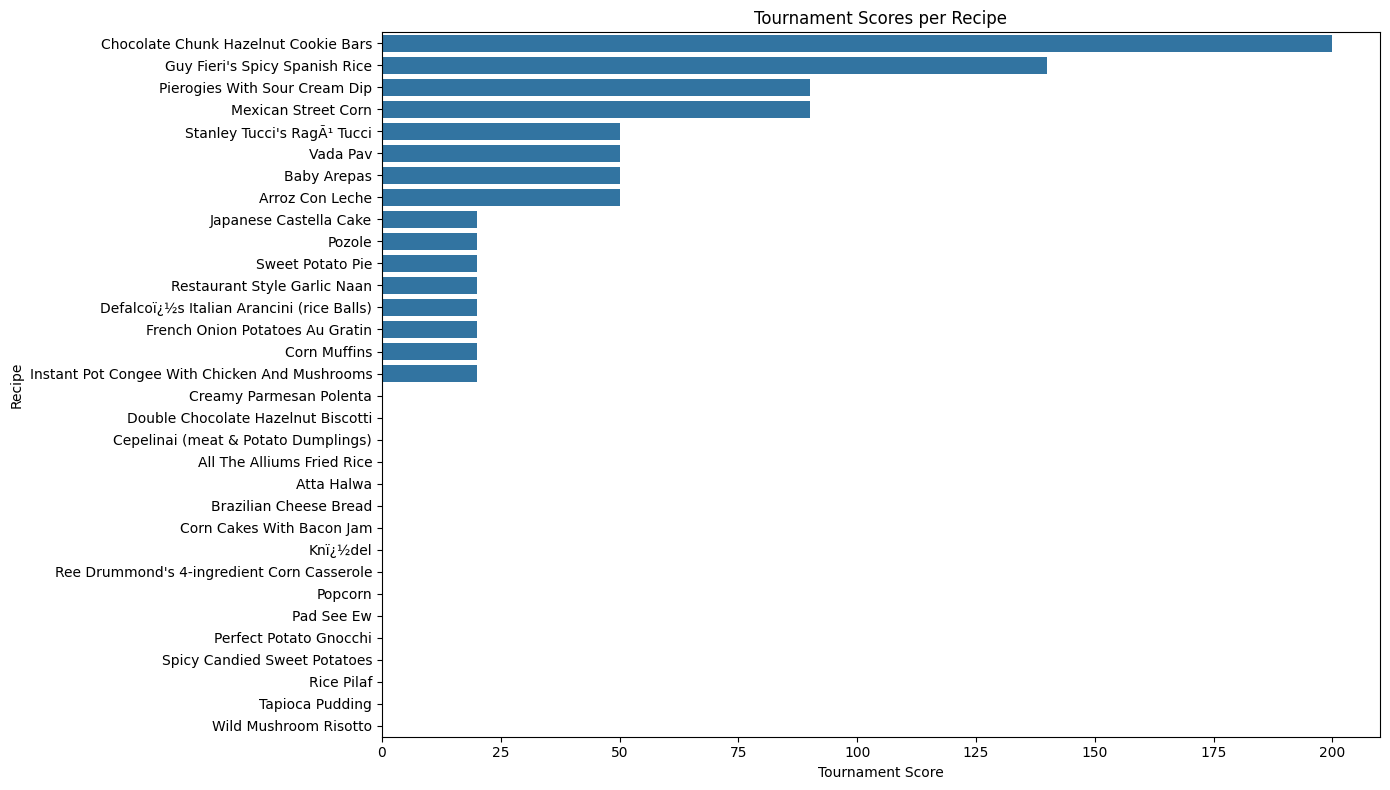

In [29]:
plt.figure(figsize=(14, 8))
df_sorted = df.sort_values('tournament_score', ascending=False)
sns.barplot(data=df_sorted, x='tournament_score', y='title')
plt.title('Tournament Scores per Recipe')
plt.xlabel('Tournament Score')
plt.ylabel('Recipe')
plt.tight_layout()
plt.show()

## Ingredient Analysis

In [30]:
ingredient_rows = []
for _, row in df.iterrows():
    for ingredient in row['normalized_ingredients']:
        ingredient_rows.append({
            'ingredient': ingredient,
            'tournament_score': row['tournament_score']
        })

ingredients_df = pd.DataFrame(ingredient_rows)

In [31]:
starch_keywords = ['potato', 'pasta', 'corn', 'bread', 'rice', 'flour', 'wheat', 'oat', 'barley', 
                   'quinoa', 'couscous', 'bulgur', 'tortilla', 'noodle', 
                   'ramen', 'udon', 'soba', 'gnocchi', 'dumpling', 'tapioca', 'sago', 
                   'polenta', 'grits', 'masa', 'arepa', 'panko', 'cracker', 'biscuit', 
                   'muffin', 'bun', 'roll', 'pizza', 'focaccia', 'naan', 'pita', 'bagel',
                   'croissant', 'baguette', 'sourdough', 'challah', 'brioche', 'pierogi',
                   'samosa', 'waffle', 'pancake', 'crepe', 'blintz', 'cornmeal', 'semolina']

def is_starch(ingredient):
    ingredient_lower = ingredient.lower()
    return any(keyword in ingredient_lower for keyword in starch_keywords)

starch_ingredients_df = ingredients_df[ingredients_df['ingredient'].apply(is_starch)]
ingredient_avg = starch_ingredients_df.groupby('ingredient')['tournament_score'].mean().reset_index()
ingredient_avg = ingredient_avg.sort_values('tournament_score', ascending=False)

## Chart 2: Scores per Starch Ingredient Type

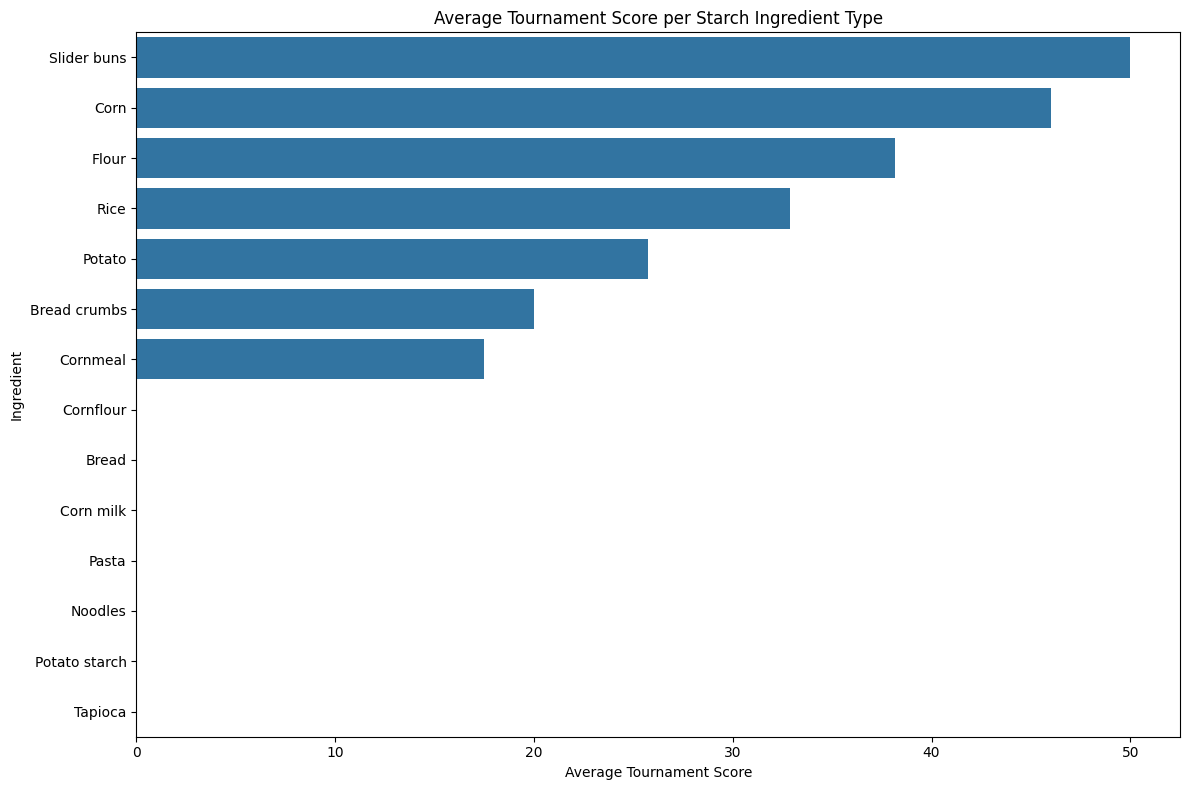

In [32]:
plt.figure(figsize=(12, 8))
sns.barplot(data=ingredient_avg, x='tournament_score', y='ingredient')
plt.title('Average Tournament Score per Starch Ingredient Type')
plt.xlabel('Average Tournament Score')
plt.ylabel('Ingredient')
plt.tight_layout()
plt.show()

## Chart 3: Ingredient Frequency (Pie Chart)

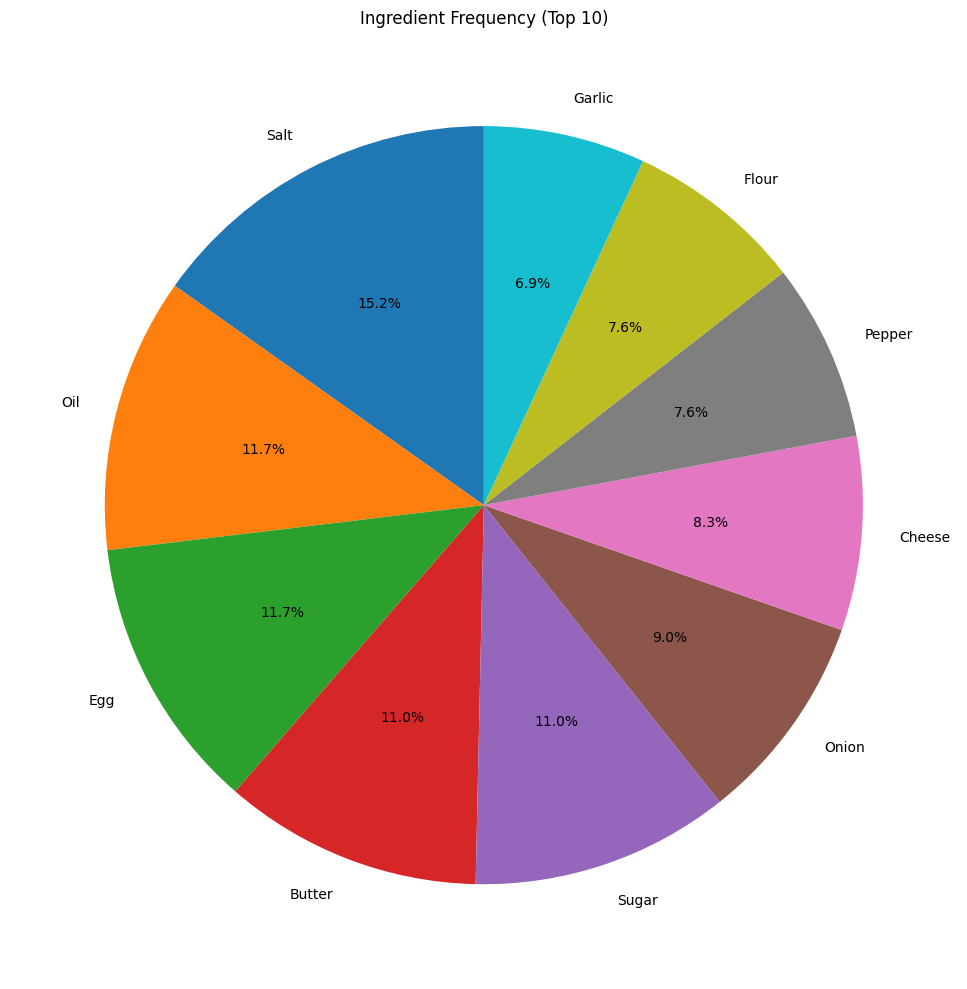

In [33]:
ingredient_counts = ingredients_df['ingredient'].value_counts().head(10)

plt.figure(figsize=(10, 10))
plt.pie(ingredient_counts, labels=ingredient_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Ingredient Frequency (Top 10)')
plt.tight_layout()
plt.show()

## Chart 3b: Starch Ingredient Frequency (Pie Chart)

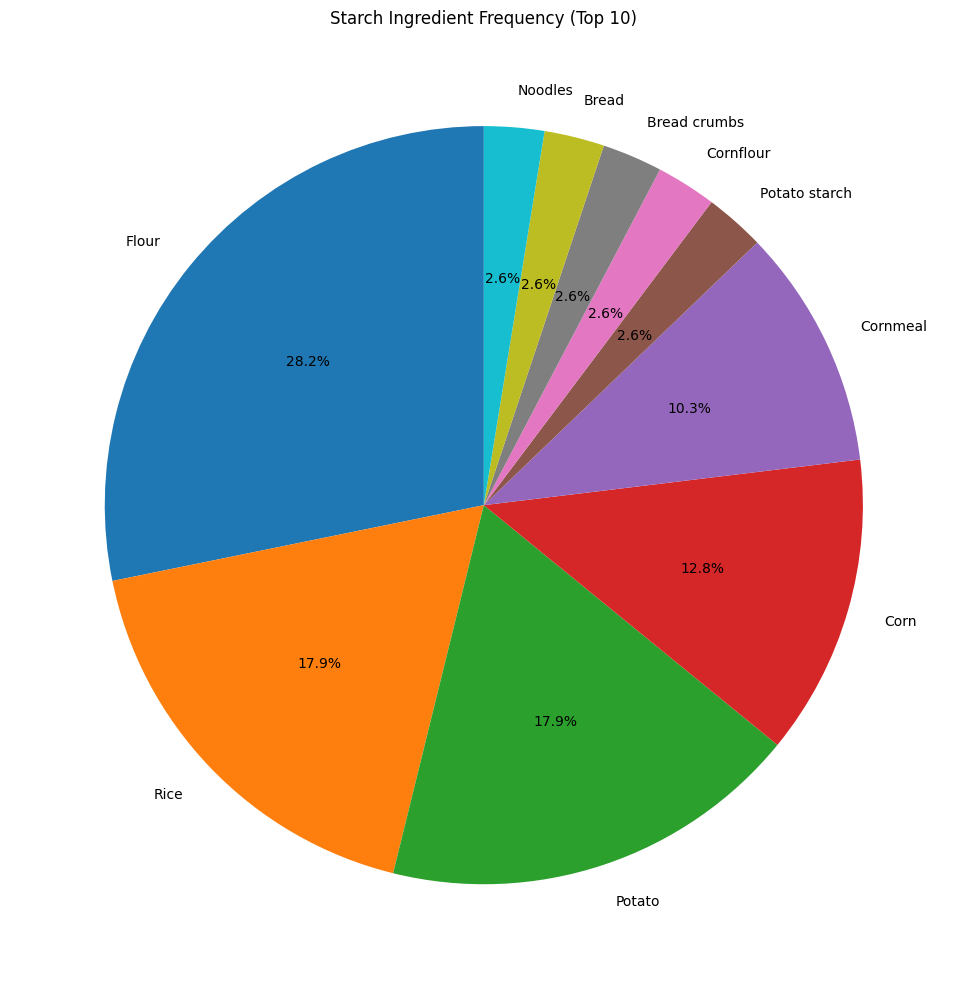

In [34]:
starch_ingredient_counts = starch_ingredients_df['ingredient'].value_counts().head(10)

plt.figure(figsize=(10, 10))
plt.pie(starch_ingredient_counts, labels=starch_ingredient_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Starch Ingredient Frequency (Top 10)')
plt.tight_layout()
plt.show()

## Ethnic Origin Analysis

In [35]:
ethnic_scores = df.groupby('ethnic_origin')['tournament_score'].sum().reset_index()
ethnic_scores = ethnic_scores.sort_values('tournament_score', ascending=False)

In [36]:
ethnic_counts = df['ethnic_origin'].value_counts().reset_index()
ethnic_counts.columns = ['ethnic_origin', 'count']

## Chart 4: Scores per Ethnic Origin

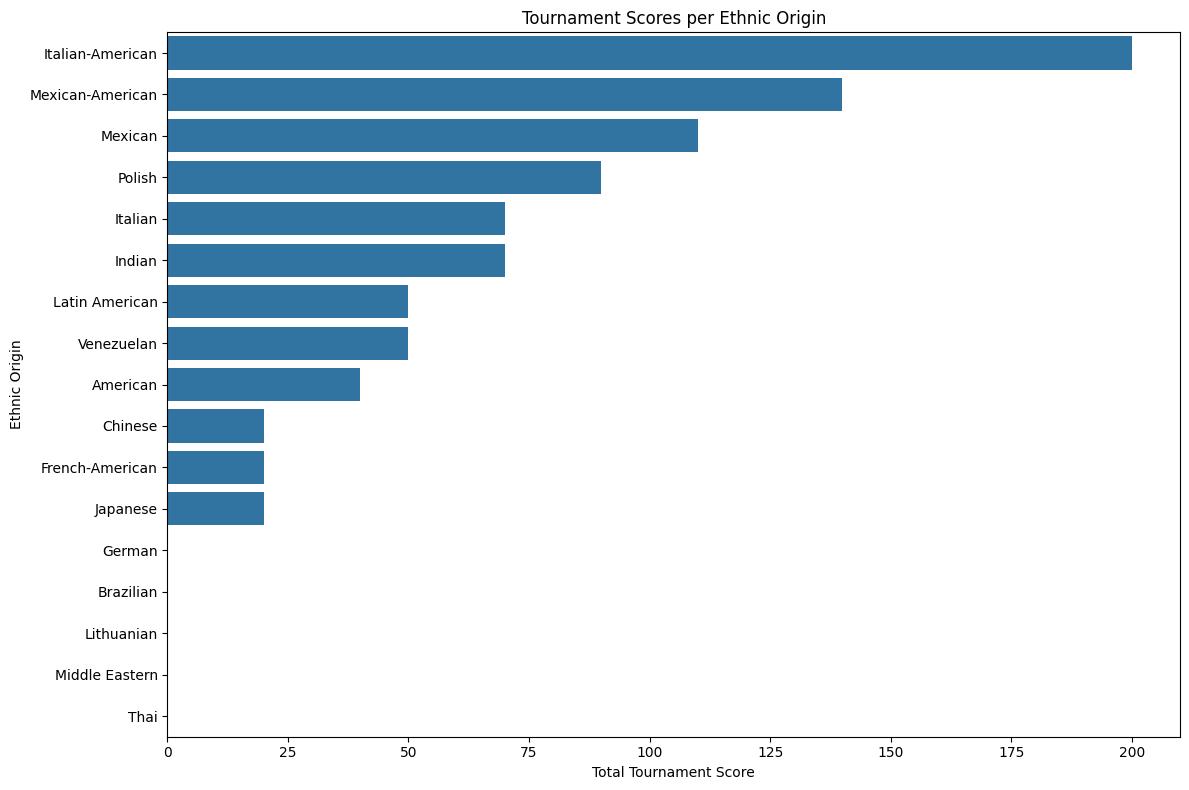

In [37]:
plt.figure(figsize=(12, 8))
sns.barplot(data=ethnic_scores, x='tournament_score', y='ethnic_origin')
plt.title('Tournament Scores per Ethnic Origin')
plt.xlabel('Total Tournament Score')
plt.ylabel('Ethnic Origin')
plt.tight_layout()
plt.show()

## Chart 5: Ethnic Origin Frequency (Pie Chart)

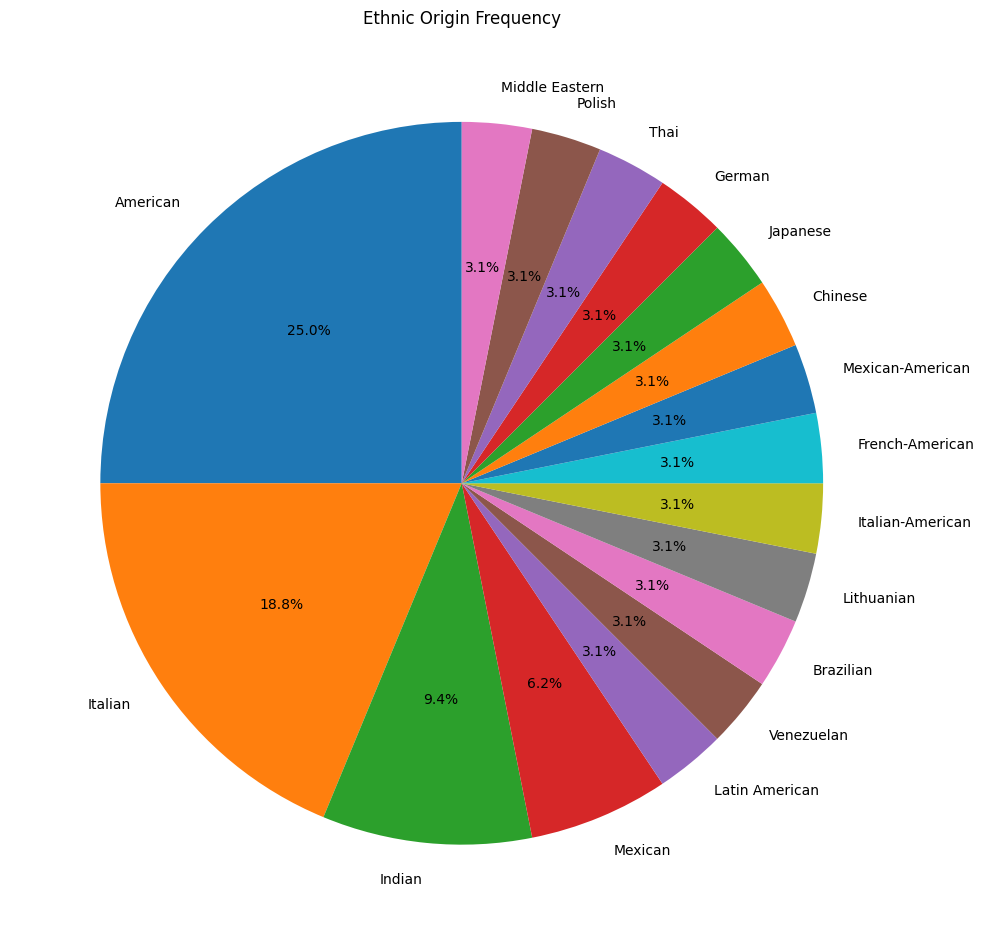

In [38]:
plt.figure(figsize=(10, 10))
plt.pie(ethnic_counts['count'], labels=ethnic_counts['ethnic_origin'], autopct='%1.1f%%', startangle=90)
plt.title('Ethnic Origin Frequency')
plt.tight_layout()
plt.show()

## Ingredient Count vs Score Analysis

In [39]:
df['ingredient_count'] = df['normalized_ingredients'].apply(len)

def bucket_ingredients(count):
    if count <= 5:
        return '1-5'
    elif count <= 10:
        return '6-10'
    elif count <= 15:
        return '11-15'
    else:
        return '15+'

df['ingredient_bucket'] = df['ingredient_count'].apply(bucket_ingredients)
ingredient_count_analysis = df.groupby('ingredient_bucket')['tournament_score'].agg(['mean', 'count', 'sum']).reset_index()
ingredient_count_analysis.columns = ['ingredient_bucket', 'avg_score', 'recipe_count', 'total_score']
bucket_order = ['1-5', '6-10', '11-15', '15+']
ingredient_count_analysis['ingredient_bucket'] = pd.Categorical(
    ingredient_count_analysis['ingredient_bucket'], categories=bucket_order, ordered=True
)
ingredient_count_analysis = ingredient_count_analysis.sort_values('ingredient_bucket')
print("Ingredient Count Analysis (Bucketed):")
print(ingredient_count_analysis.to_string(index=False))

Ingredient Count Analysis (Bucketed):
ingredient_bucket  avg_score  recipe_count  total_score
              1-5  15.000000             6           90
             6-10  11.818182            11          130
            11-15  36.000000            10          360
              15+  60.000000             5          300


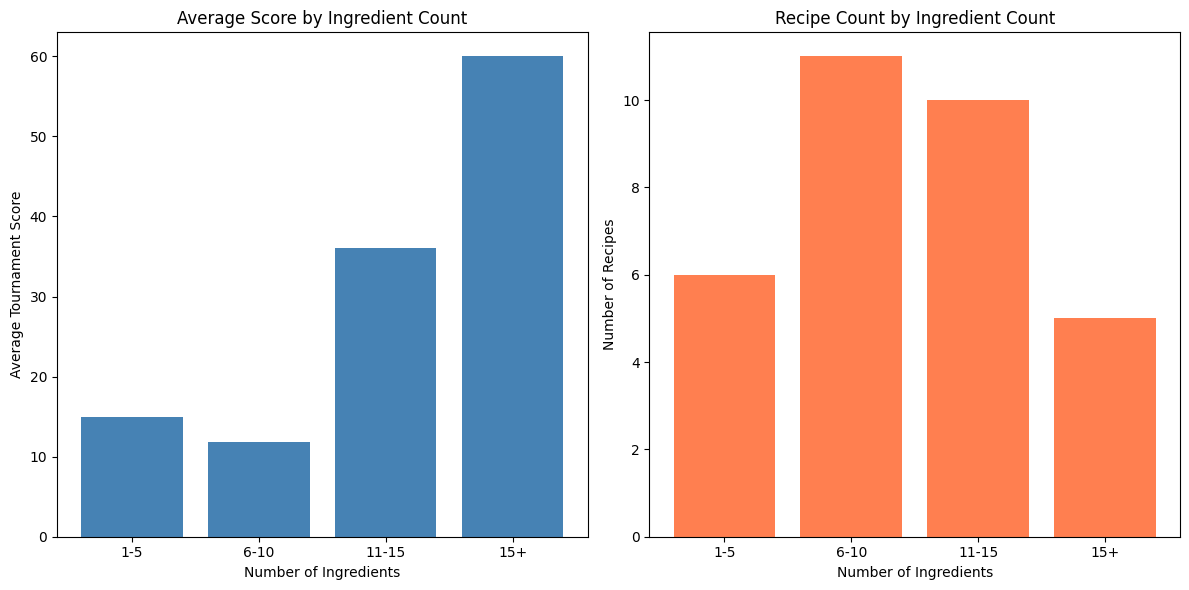

In [40]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(ingredient_count_analysis['ingredient_bucket'], ingredient_count_analysis['avg_score'], color='steelblue')
plt.xlabel('Number of Ingredients')
plt.ylabel('Average Tournament Score')
plt.title('Average Score by Ingredient Count')

plt.subplot(1, 2, 2)
plt.bar(ingredient_count_analysis['ingredient_bucket'], ingredient_count_analysis['recipe_count'], color='coral')
plt.xlabel('Number of Ingredients')
plt.ylabel('Number of Recipes')
plt.title('Recipe Count by Ingredient Count')

plt.tight_layout()
plt.show()

## Chart 6: Total Votes per Round

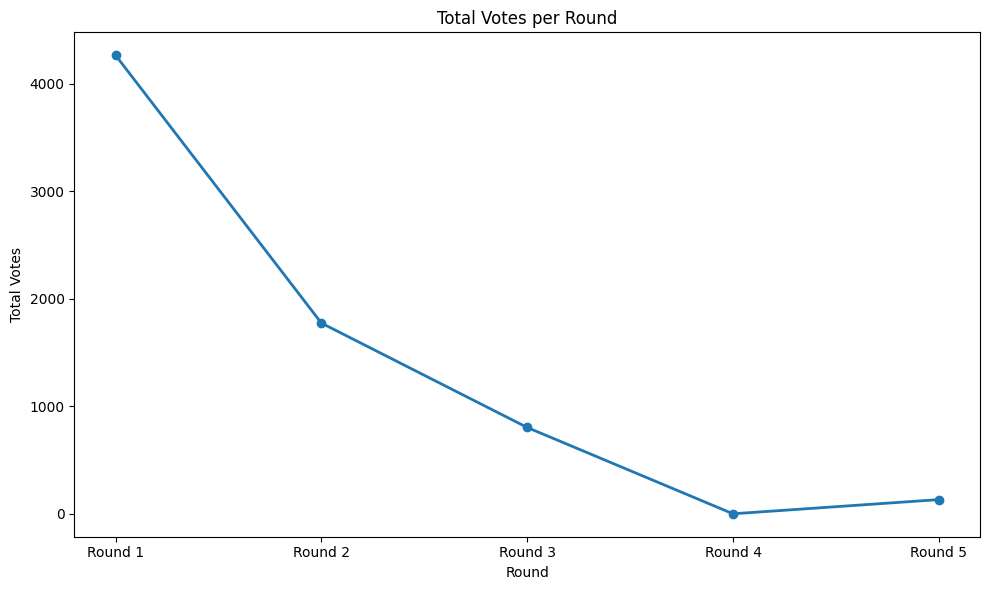

In [41]:
vote_columns = ['vote_count_round_one', 'vote_count_round_two', 'vote_count_round_three', 
                'vote_count_round_four', 'vote_count_round_five']

total_votes = df[vote_columns].fillna(0).sum().values
rounds = ['Round 1', 'Round 2', 'Round 3', 'Round 4', 'Round 5']

plt.figure(figsize=(10, 6))
plt.plot(rounds, total_votes, marker='o', linewidth=2)
plt.title('Total Votes per Round')
plt.xlabel('Round')
plt.ylabel('Total Votes')
plt.tight_layout()
plt.show()

## Celebrity Author Analysis

In [42]:
df['author_type'] = df['written_by_celebrity_author'].map({True: 'Celebrity Author', False: 'Non-Celebrity'})

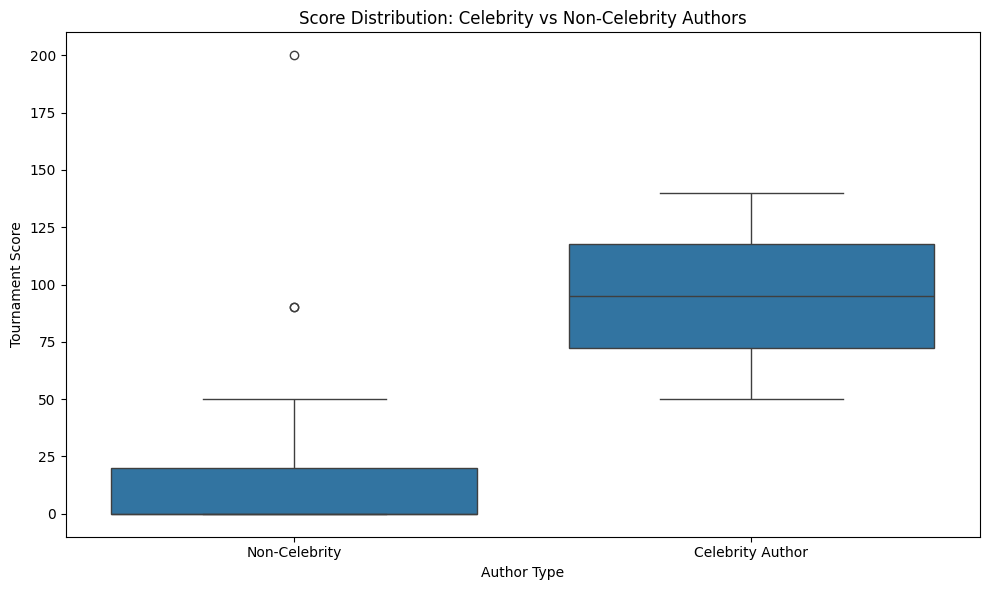

In [43]:
if df[df['author_type'] == 'Celebrity Author'].empty:
    print("No celebrity authors in dataset")
else:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='author_type', y='tournament_score')
    plt.title('Score Distribution: Celebrity vs Non-Celebrity Authors')
    plt.xlabel('Author Type')
    plt.ylabel('Tournament Score')
    plt.tight_layout()
    plt.show()

## Normalized Voting Analysis

In [44]:
matchups_per_round = [16, 8, 4, 2, 1]

total_votes = df[vote_columns].fillna(0).sum().values
normalized_votes = total_votes / matchups_per_round

print("Normalized Votes per Matchup by Round:")
for i, (round_name, norm_votes) in enumerate(zip(rounds, normalized_votes)):
    print(f"  {round_name}: {norm_votes:.2f} votes/matchup")

Normalized Votes per Matchup by Round:
  Round 1: 266.56 votes/matchup
  Round 2: 221.75 votes/matchup
  Round 3: 200.75 votes/matchup
  Round 4: 0.00 votes/matchup
  Round 5: 132.00 votes/matchup


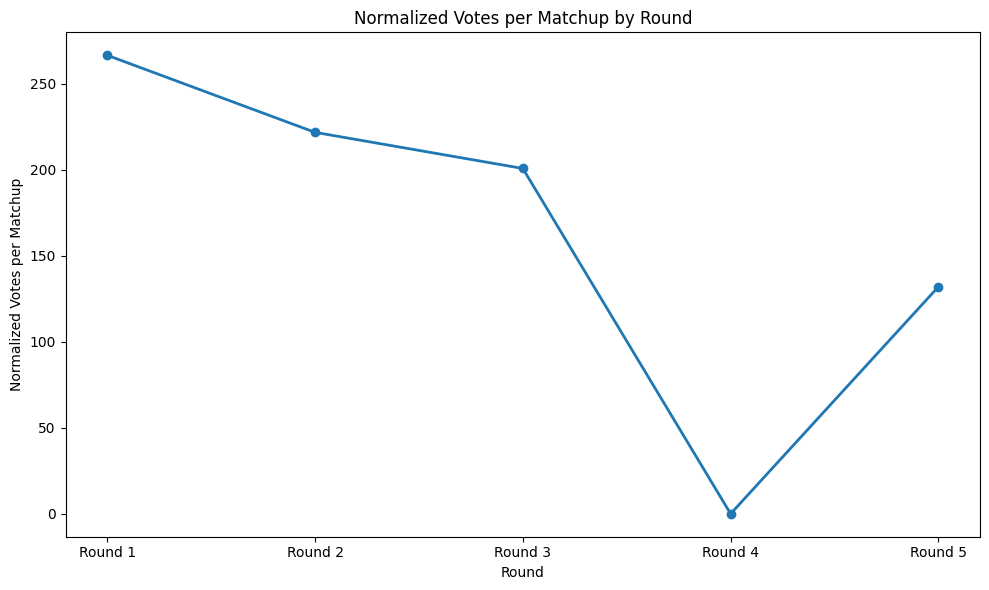

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(rounds, normalized_votes, marker='o', linewidth=2)
plt.title('Normalized Votes per Matchup by Round')
plt.xlabel('Round')
plt.ylabel('Normalized Votes per Matchup')
plt.tight_layout()
plt.show()

## Summary Statistics

In [46]:
print("=== Summary Statistics ===")
print(f"Total Recipes: {len(df)}")
print(f"Average Tournament Score: {df['tournament_score'].mean():.2f}")
print(f"Highest Score: {df['tournament_score'].max()}")
print(f"Total Votes Round 1: {df['vote_count_round_one'].sum()}")
celebrity_count = len(df[df['author_type'] == 'Celebrity Author'])
noncelebrity_count = len(df[df['author_type'] == 'Non-Celebrity'])
print(f"Celebrity Authors: {celebrity_count}")
print(f"Non-Celebrity Authors: {noncelebrity_count}")

=== Summary Statistics ===
Total Recipes: 32
Average Tournament Score: 27.50
Highest Score: 200
Total Votes Round 1: 4265
Celebrity Authors: 2
Non-Celebrity Authors: 30
